# exp014 deep EDA

## 0. Experiment Metadata

In [2]:
# ========================================
# EXPERIMENT CONFIG
# ========================================

EXP_NAME = "exp014_deep_EDA"
TARGET = "Churn"
ID_COL = "id"

N_SPLITS = 5
SEED = 42

print(f"Running {EXP_NAME}")

Running exp014_deep_EDA


## 1. Imports

In [3]:
# ========================================
# IMPORTS
# ========================================

import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import lightgbm as lgb
import xgboost as xgb

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',50)

## 2. Reproducibility

In [4]:
# ========================================
# SEED EVERYTHING
# ========================================

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

## 3. Load Data

In [31]:
# ========================================
# LOAD DATA
# ========================================

DATA_PATH = "/Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/data/raw/"

train = pd.read_csv(DATA_PATH + "train.csv")
test = pd.read_csv(DATA_PATH + "test.csv")

print(train.shape, test.shape)
train.head()

(594194, 21) (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## 4. Quick Sanity Checs (Fast EDA)

In [32]:
# ========================================
# QUICK EDA
# ========================================

print("Target distribution:")
print(train['Churn'].value_counts(normalize=True))

print("\nMissing values (top 10):")
print(train.isnull().mean().sort_values(ascending=False).head(10))

Target distribution:
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64

Missing values (top 10):
id                  0.0
DeviceProtection    0.0
TotalCharges        0.0
MonthlyCharges      0.0
PaymentMethod       0.0
PaperlessBilling    0.0
Contract            0.0
StreamingMovies     0.0
StreamingTV         0.0
TechSupport         0.0
dtype: float64


### Deep EDA

In [8]:
train.head(5)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [10]:
def plot_num_feature_vs_target(feature, df, target, bins=10, method="quantile"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    data = df[[feature, target]].copy()

    # 🔥 FIX TARGET
    if data[target].dtype == "object":
        data[target] = data[target].map({"No": 0, "Yes": 1})

    data = data.dropna()

    # BINNING
    if method == "quantile":
        data["bin"] = pd.qcut(data[feature], q=bins, duplicates="drop")
    else:
        data["bin"] = pd.cut(data[feature], bins=bins)

    grouped = data.groupby("bin")

    churn_rate = grouped[target].mean()
    counts = grouped[target].count()

    fig, ax1 = plt.subplots(figsize=(14,6))

    counts.plot(kind="bar", ax=ax1)
    ax1.set_ylabel("Count")

    ax2 = ax1.twinx()
    ax2.plot(range(len(churn_rate)), churn_rate.values, marker="o")
    ax2.set_ylabel("Churn Rate")

    plt.title(f"{feature} vs {target}")
    plt.show()

    print(pd.DataFrame({
        "count": counts,
        "churn_rate": churn_rate
    }))

In [24]:
def plot_cat_feature_vs_target(feature, df, target, top_n=10, show_table=True):

    df = df.loc[:, ~df.columns.duplicated()]
    data = df[[feature, target]].copy()

    # ✅ ensure target is 1D
    if isinstance(data[target], pd.DataFrame):
        data[target] = data[target].iloc[:, 0]

    # ✅ convert target to numeric
    if data[target].dtype == "object":
        data[target] = data[target].map({"No": 0, "Yes": 1})

    # ✅ handle missing
    data[feature] = data[feature].fillna("MISSING")

    # ✅ limit categories (avoid messy plots)
    top_categories = data[feature].value_counts().nlargest(top_n).index
    data[feature] = data[feature].where(data[feature].isin(top_categories), "OTHER")

    # ✅ aggregation (THIS IS WHAT YOU WANT)
    agg = (
        data.groupby(feature)[target]
        .agg(count="count", churn_rate="mean")
        .sort_values("churn_rate", ascending=False)
    )

    # ✅ PRINT TABLE (🔥 IMPORTANT)
    if show_table:
        print("\n")
        print(f"===== {feature} =====")
        print(agg)

    # ✅ PLOT
    fig, ax1 = plt.subplots(figsize=(12,6))

    ax1.bar(agg.index, agg["count"])
    ax1.set_ylabel("Count")

    ax2 = ax1.twinx()
    ax2.plot(agg.index, agg["churn_rate"], marker="o")
    ax2.set_ylabel("Churn Rate")

    plt.title(f"{feature} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

In [13]:
# ========================================
# DETECT COLUMN TYPES
# ========================================

TARGET = "Churn"

# Numerical columns
num_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove target if inside
if TARGET in num_cols:
    num_cols.remove(TARGET)

# Categorical columns (object + category)
cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()

# OPTIONAL: treat low-cardinality numeric as categorical
for col in num_cols.copy():
    if train[col].nunique() < 10:
        num_cols.remove(col)
        cat_cols.append(col)

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['id', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen']



===== id =====


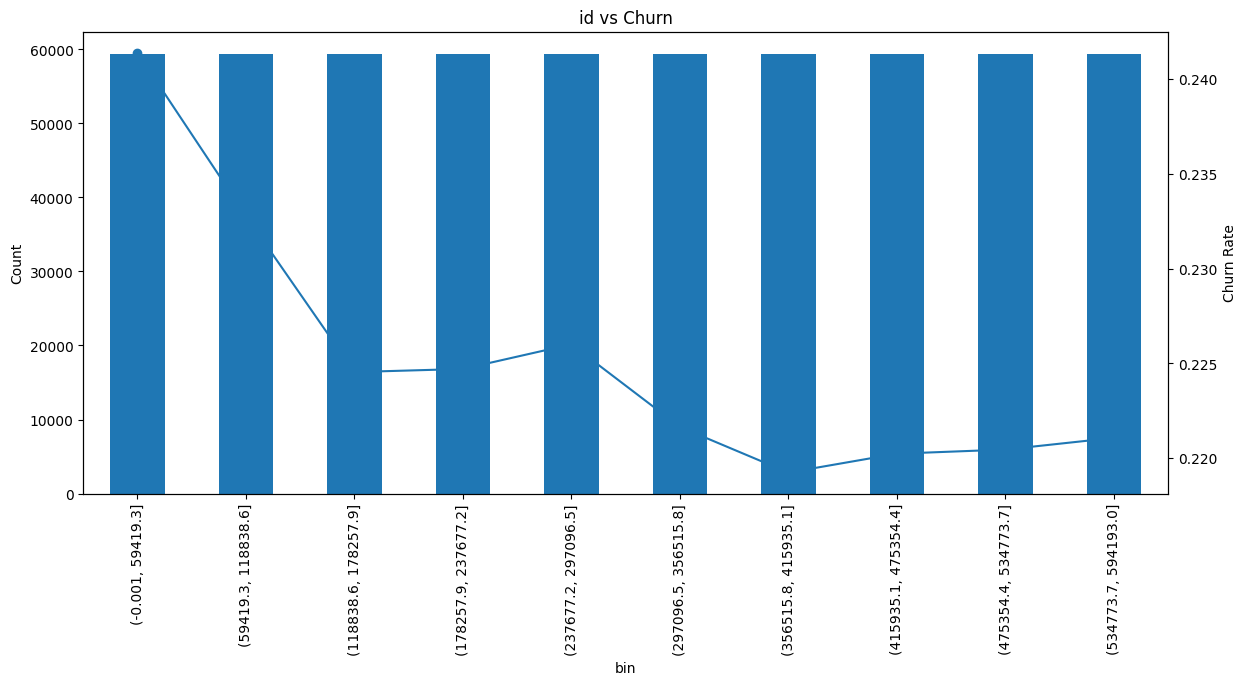

                      count  churn_rate
bin                                    
(-0.001, 59419.3]     59420    0.241400
(59419.3, 118838.6]   59419    0.232787
(118838.6, 178257.9]  59419    0.224541
(178257.9, 237677.2]  59420    0.224705
(237677.2, 297096.5]  59419    0.226005
(297096.5, 356515.8]  59419    0.221646
(356515.8, 415935.1]  59420    0.219236
(415935.1, 475354.4]  59419    0.220233
(475354.4, 534773.7]  59419    0.220451
(534773.7, 594193.0]  59420    0.221070

===== tenure =====


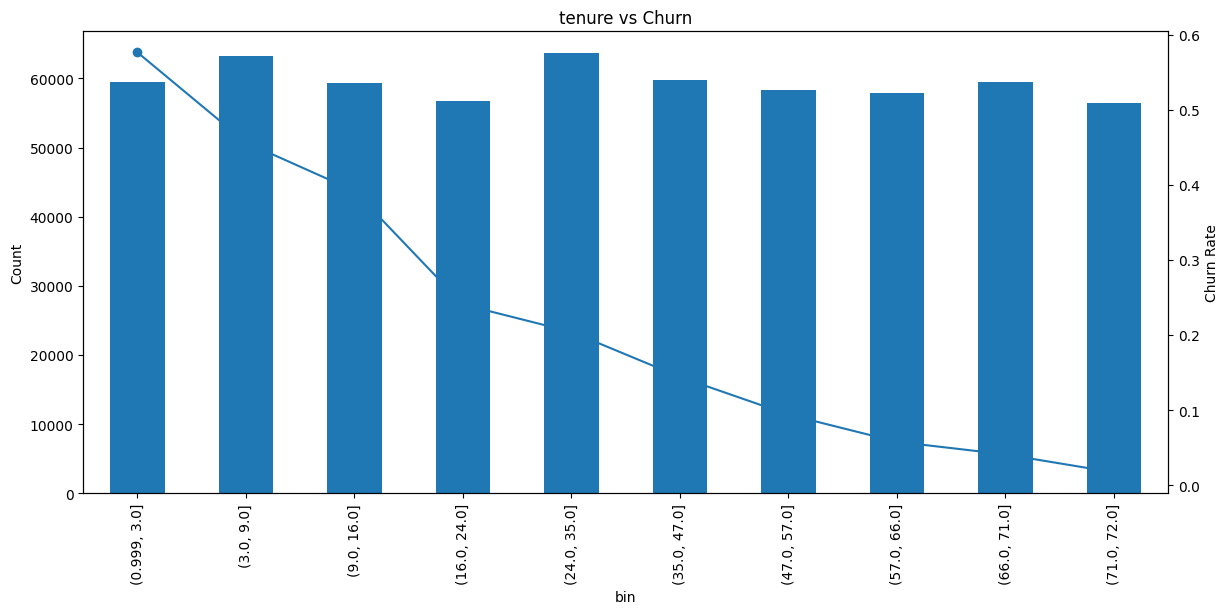

              count  churn_rate
bin                            
(0.999, 3.0]  59426    0.576347
(3.0, 9.0]    63173    0.456366
(9.0, 16.0]   59358    0.391809
(16.0, 24.0]  56713    0.240615
(24.0, 35.0]  63613    0.204125
(35.0, 47.0]  59805    0.144135
(47.0, 57.0]  58335    0.093992
(57.0, 66.0]  57940    0.057784
(66.0, 71.0]  59420    0.040979
(71.0, 72.0]  56411    0.017071

===== MonthlyCharges =====


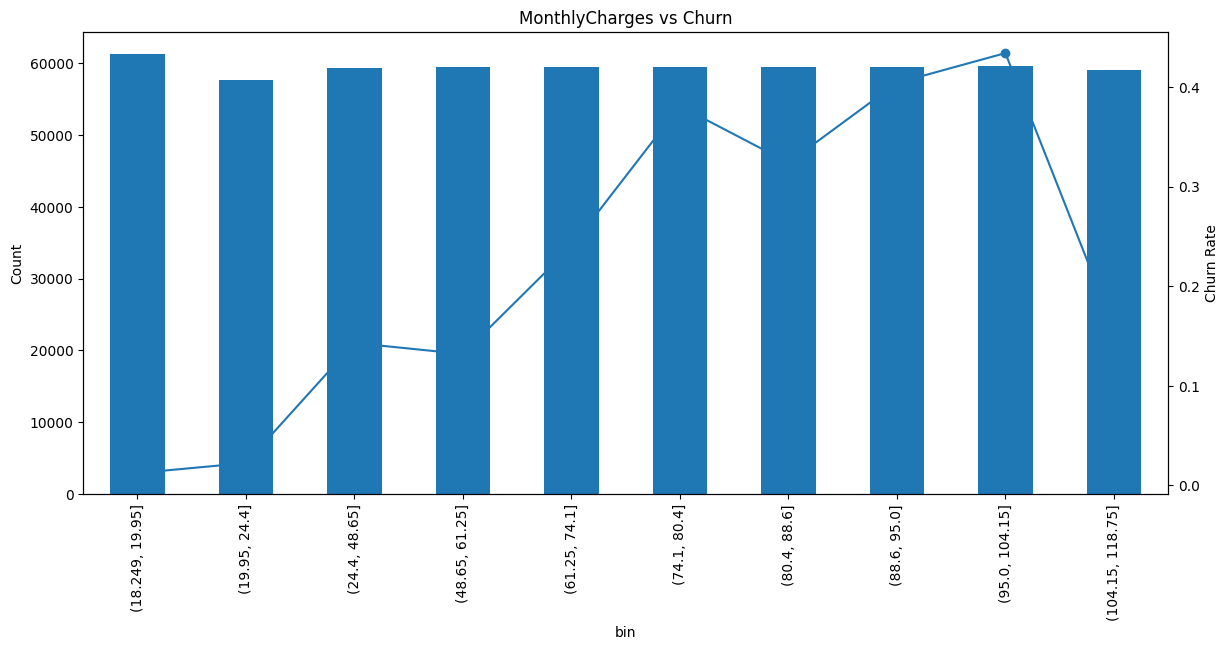

                  count  churn_rate
bin                                
(18.249, 19.95]   61266    0.012323
(19.95, 24.4]     57619    0.022441
(24.4, 48.65]     59399    0.143016
(48.65, 61.25]    59401    0.131917
(61.25, 74.1]     59449    0.239886
(74.1, 80.4]      59496    0.380933
(80.4, 88.6]      59448    0.324065
(88.6, 95.0]      59515    0.404201
(95.0, 104.15]    59602    0.434147
(104.15, 118.75]  58999    0.157901

===== TotalCharges =====


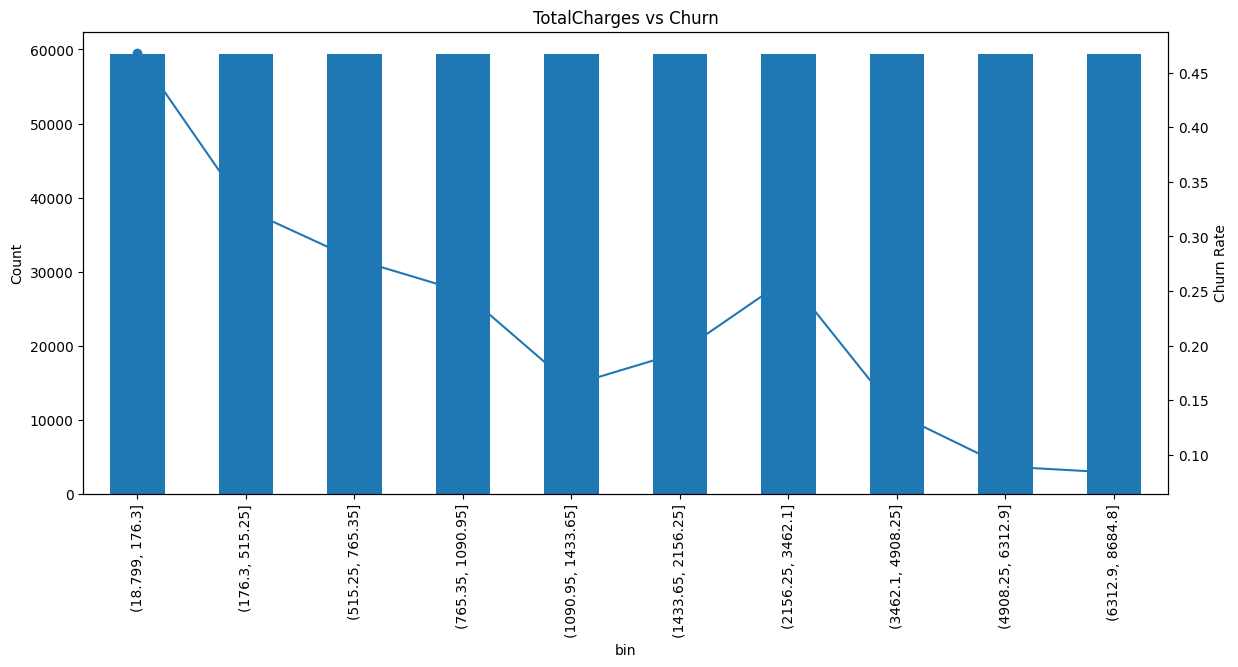

                    count  churn_rate
bin                                  
(18.799, 176.3]     59431    0.468308
(176.3, 515.25]     59410    0.324861
(515.25, 765.35]    59446    0.279245
(765.35, 1090.95]   59399    0.249499
(1090.95, 1433.65]  59416    0.163811
(1433.65, 2156.25]  59441    0.193705
(2156.25, 3462.1]   59401    0.261982
(3462.1, 4908.25]   59439    0.137603
(4908.25, 6312.9]   59418    0.089249
(6312.9, 8684.8]    59393    0.083747


In [15]:
# ========================================
# NUMERICAL EDA LOOP
# ========================================

for col in num_cols:
    print(f"\n===== {col} =====")
    plot_num_feature_vs_target(col, train, TARGET)


===== gender =====


===== gender =====
         count  churn_rate
gender                    
Female  298738    0.228036
Male    295456    0.222348


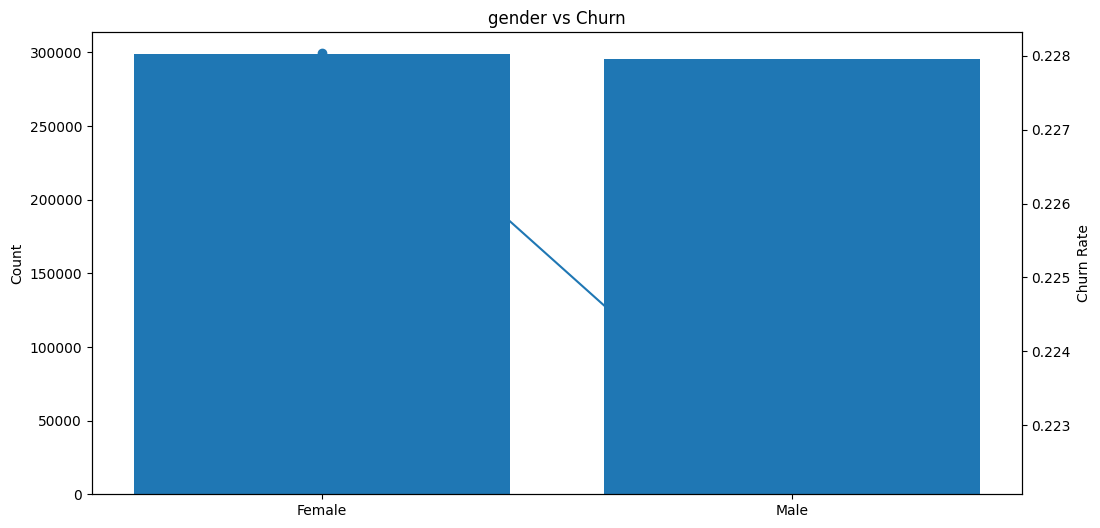


===== Partner =====


===== Partner =====
          count  churn_rate
Partner                    
No       284640    0.324621
Yes      309554    0.133796


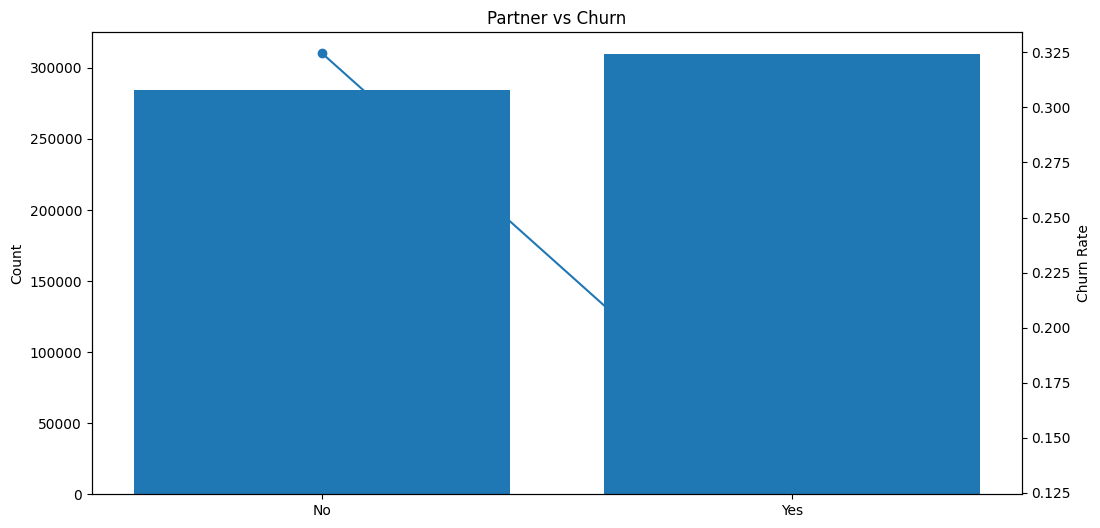


===== Dependents =====


===== Dependents =====
             count  churn_rate
Dependents                    
No          414362    0.291354
Yes         179832    0.072796


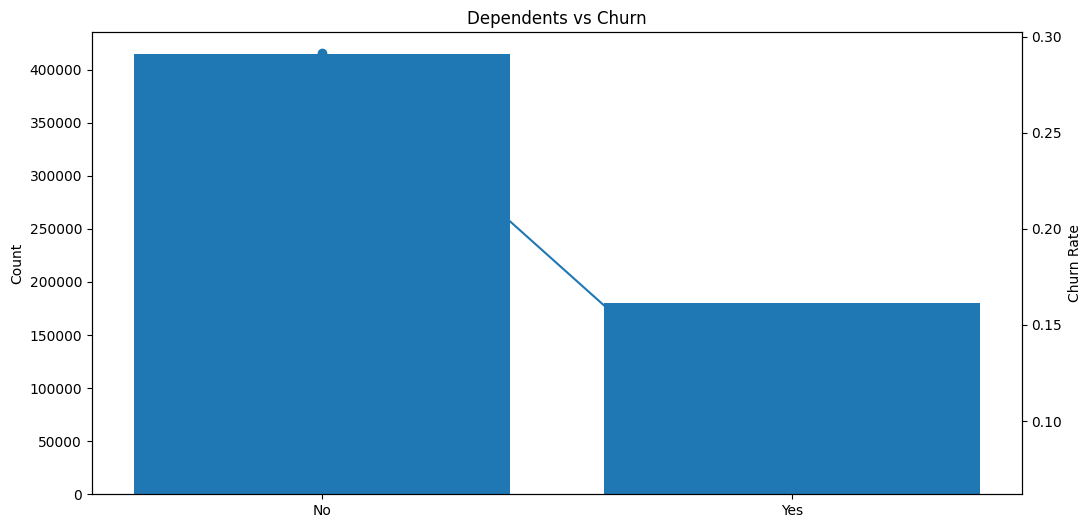


===== PhoneService =====


===== PhoneService =====
               count  churn_rate
PhoneService                    
Yes           557893     0.22892
No             36301     0.16815


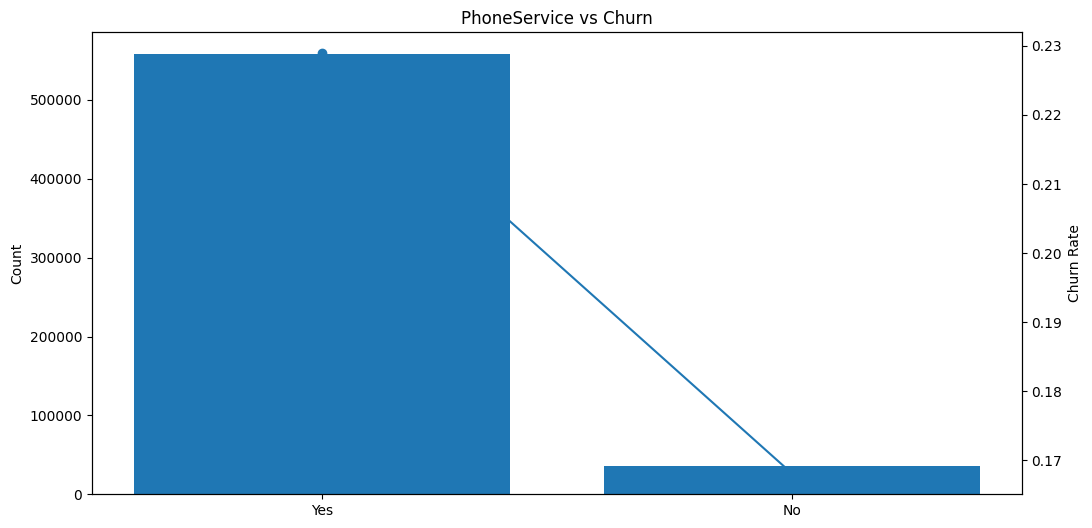


===== MultipleLines =====


===== MultipleLines =====
                   count  churn_rate
MultipleLines                       
Yes               274509    0.277026
No                283384    0.182322
No phone service   36301    0.168150


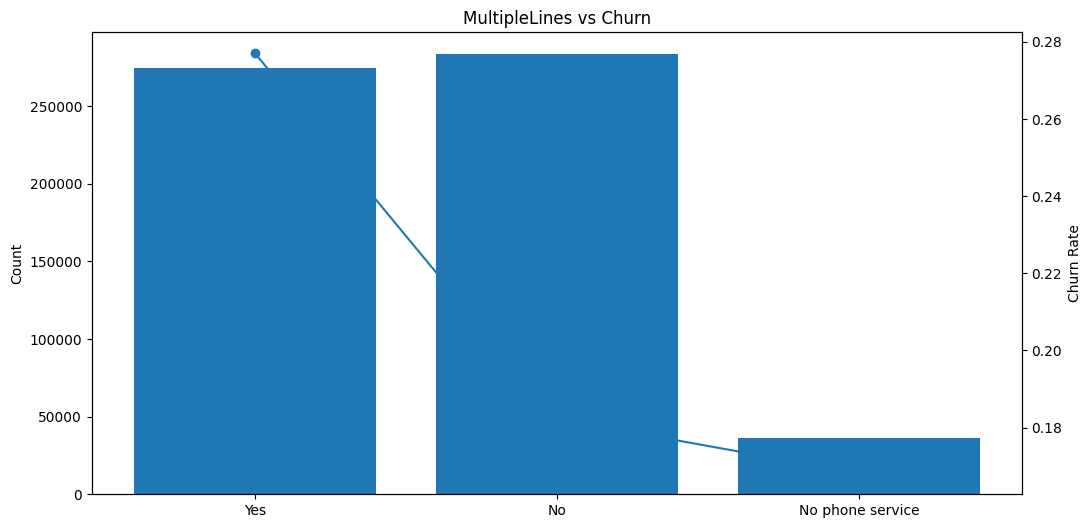


===== InternetService =====


===== InternetService =====
                  count  churn_rate
InternetService                    
Fiber optic      272386    0.415366
DSL              181081    0.103064
No               140727    0.014311


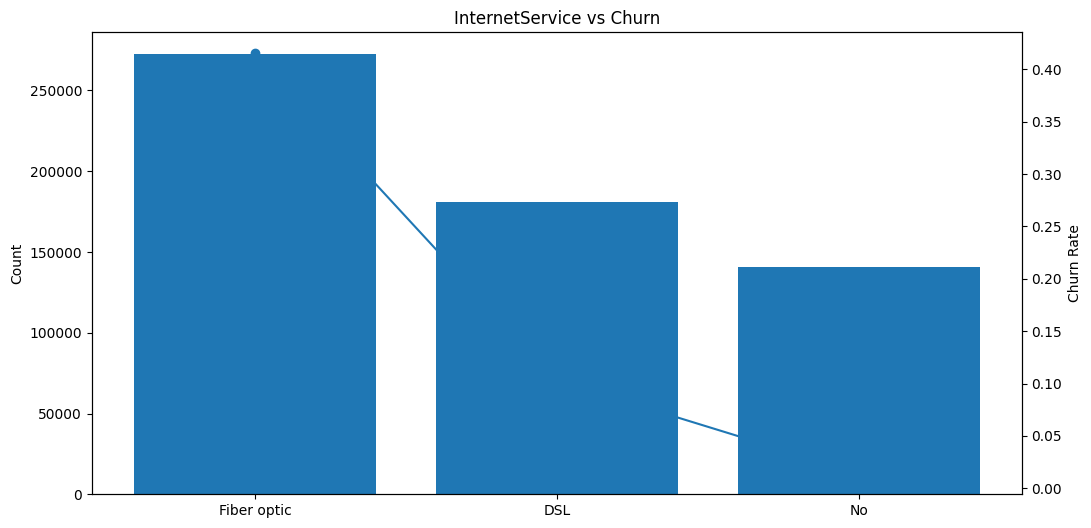


===== OnlineSecurity =====


===== OnlineSecurity =====
                      count  churn_rate
OnlineSecurity                         
No                   289474    0.406133
Yes                  163993    0.086821
No internet service  140727    0.014311


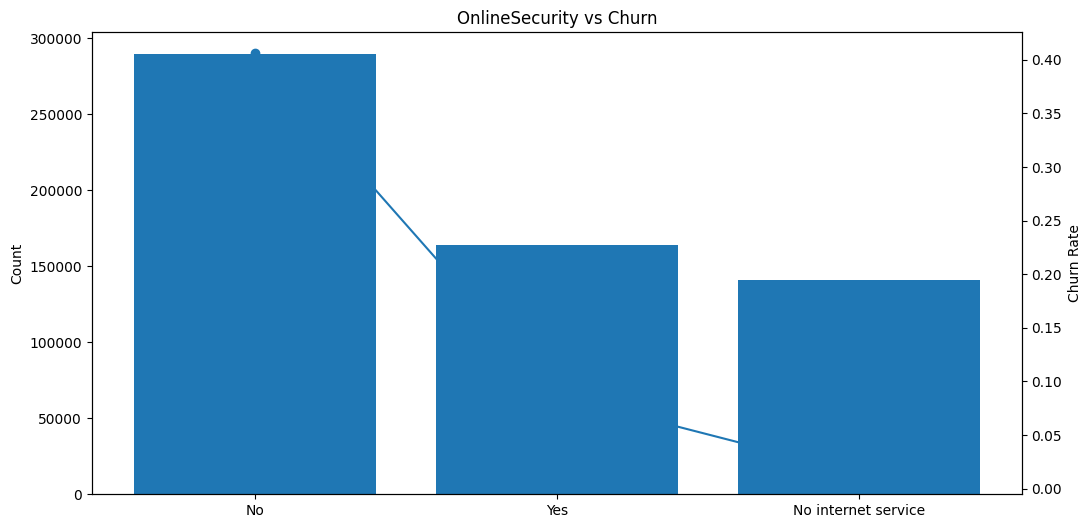


===== OnlineBackup =====


===== OnlineBackup =====
                      count  churn_rate
OnlineBackup                           
No                   250083    0.391026
Yes                  203384    0.167240
No internet service  140727    0.014311


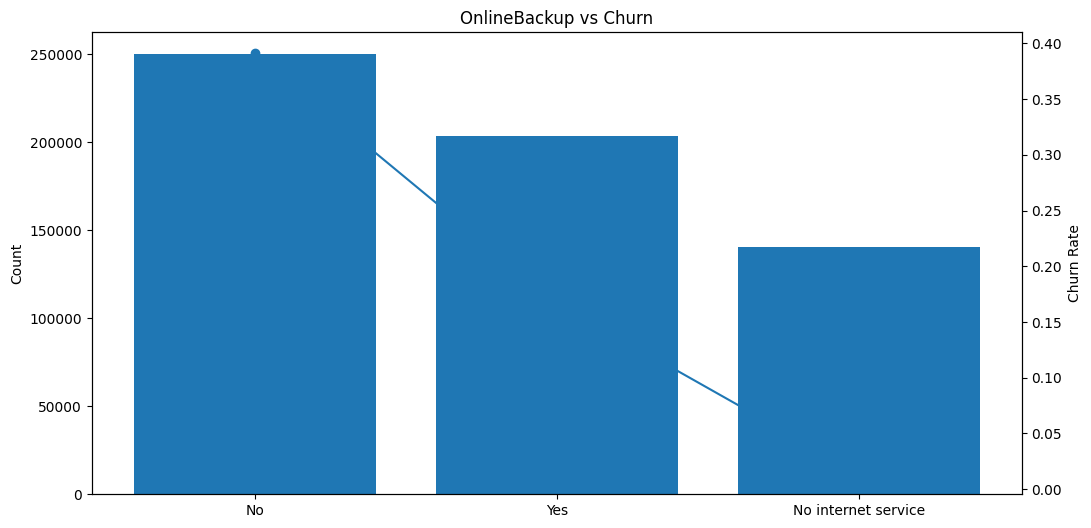


===== DeviceProtection =====


===== DeviceProtection =====
                      count  churn_rate
DeviceProtection                       
No                   247377    0.380630
Yes                  206090    0.182658
No internet service  140727    0.014311


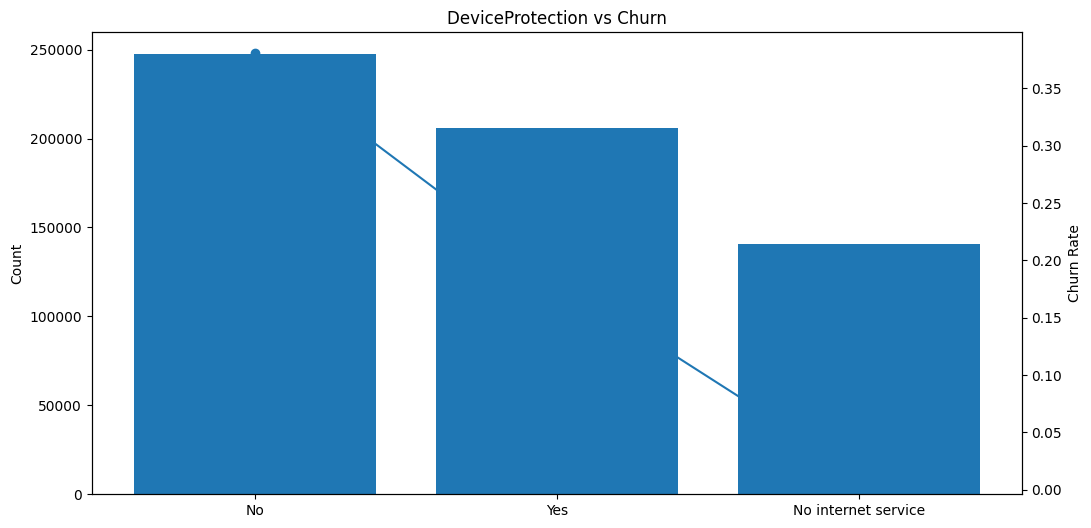


===== TechSupport =====


===== TechSupport =====
                      count  churn_rate
TechSupport                            
No                   288571    0.401620
Yes                  164896    0.096467
No internet service  140727    0.014311


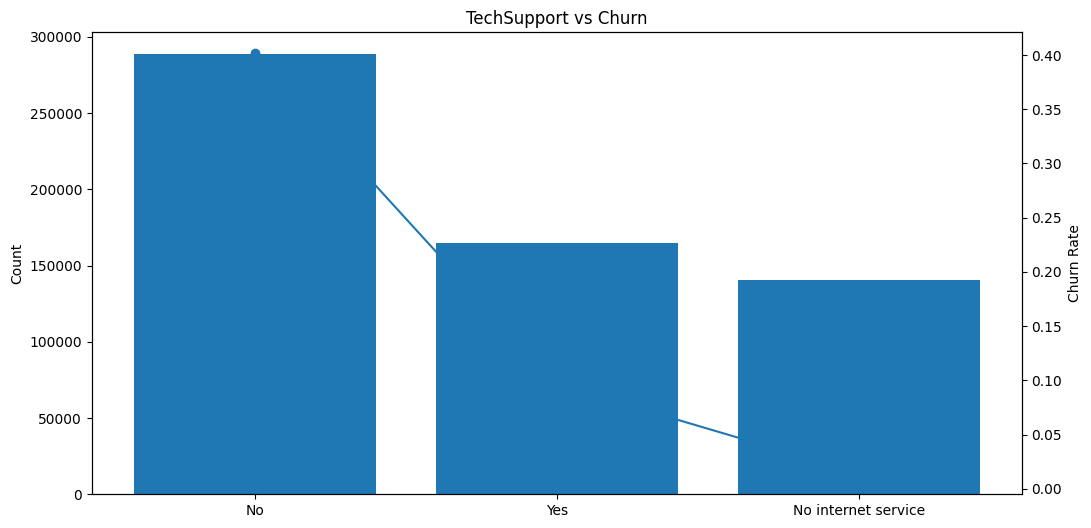


===== StreamingTV =====


===== StreamingTV =====
                      count  churn_rate
StreamingTV                            
No                   213166    0.297416
Yes                  240301    0.284660
No internet service  140727    0.014311


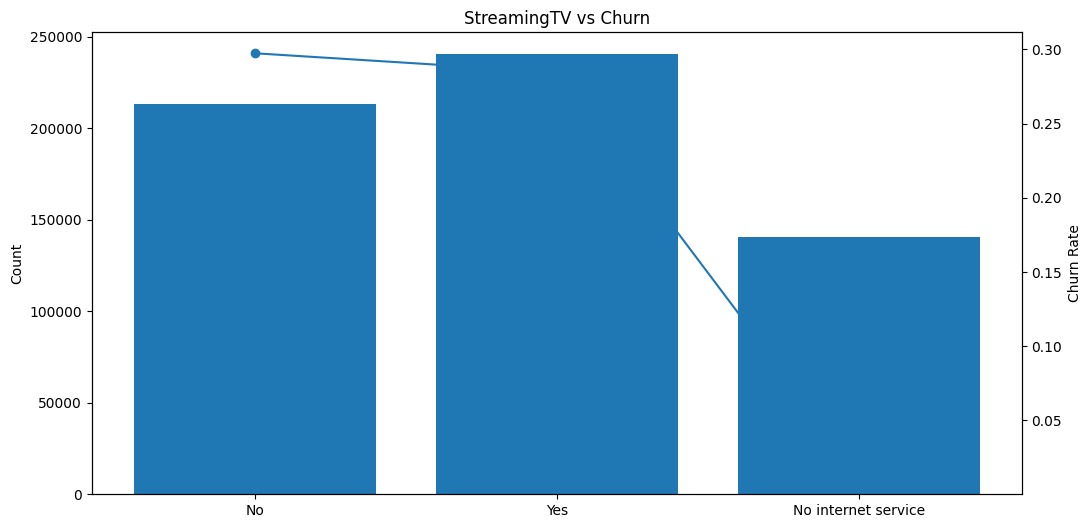


===== StreamingMovies =====


===== StreamingMovies =====
                      count  churn_rate
StreamingMovies                        
No                   212032    0.299299
Yes                  241435    0.283066
No internet service  140727    0.014311


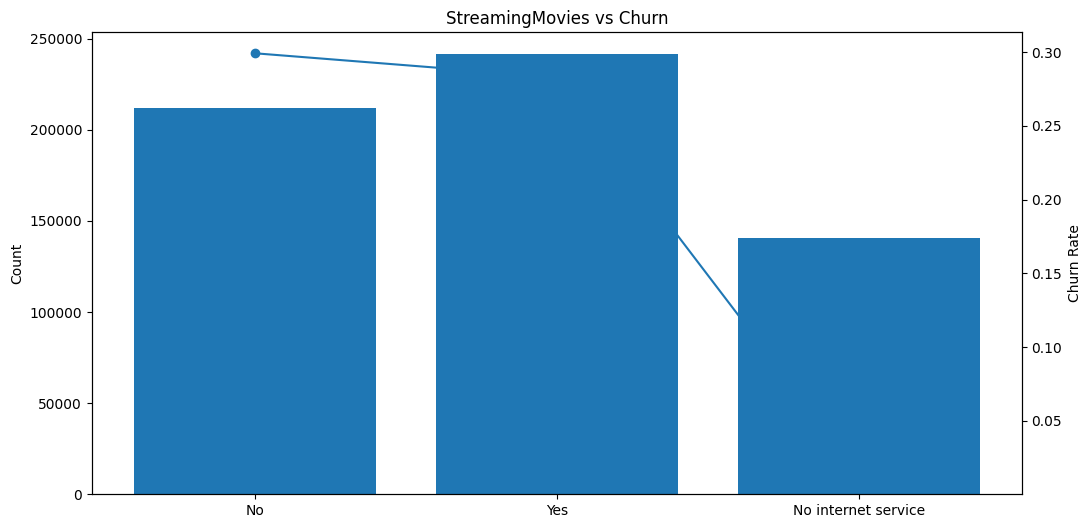


===== Contract =====


===== Contract =====
                 count  churn_rate
Contract                          
Month-to-month  298918    0.420543
One year        108333    0.057628
Two year        186943    0.009982


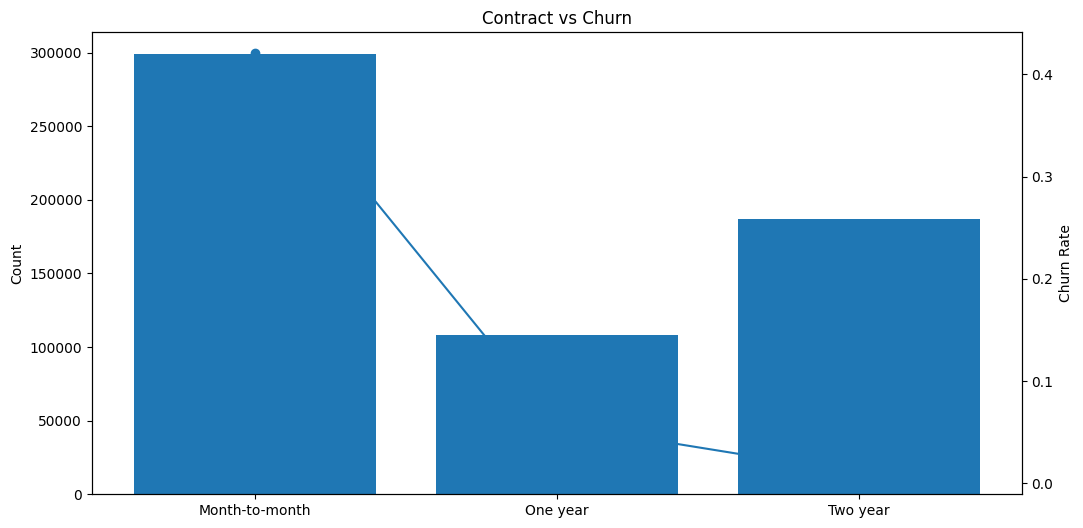


===== PaperlessBilling =====


===== PaperlessBilling =====
                   count  churn_rate
PaperlessBilling                    
Yes               365579    0.319387
No                228615    0.074606


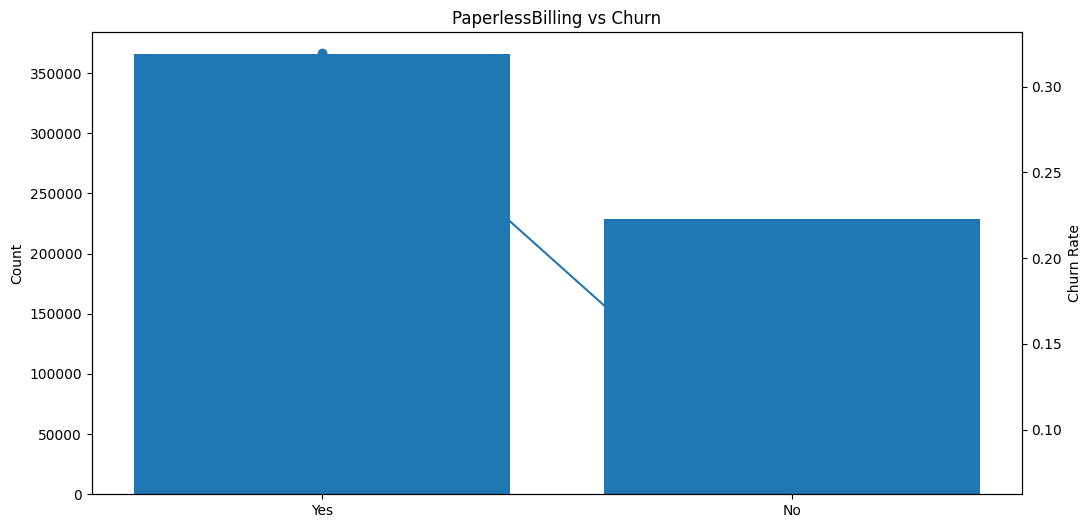


===== PaymentMethod =====


===== PaymentMethod =====
                            count  churn_rate
PaymentMethod                                
Electronic check           215372    0.489052
Mailed check               123757    0.079697
Bank transfer (automatic)  121360    0.077093
Credit card (automatic)    133705    0.069332


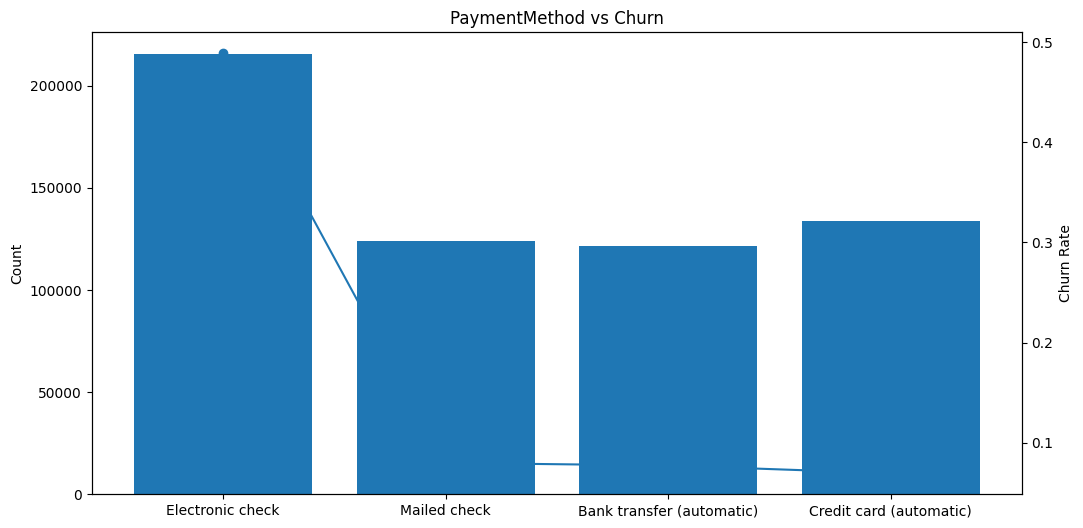


===== SeniorCitizen =====


===== SeniorCitizen =====
                count  churn_rate
SeniorCitizen                    
1               67799    0.500317
0              526395    0.189774


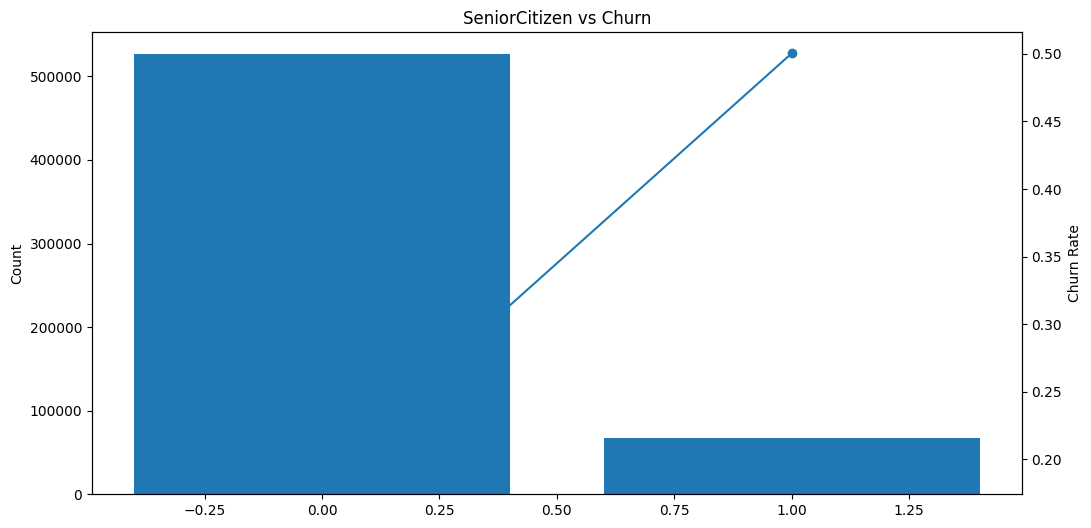

In [25]:
# ========================================
# CATEGORICAL EDA LOOP
# ========================================
if "Churn" in cat_cols:
    cat_cols.remove("Churn")

for col in cat_cols:
    print(f"\n===== {col} =====")
    plot_cat_feature_vs_target(col, train, TARGET)

## 5. Feature Engineering 

In [33]:
# ========================================
# FEATURE ENGINEERING (EXP007 - STRUCTURED SERVICE + BEST FEATURES)
# ========================================

internet_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

def create_features(df):
    df = df.copy()

    # ========================================
    # CLEANING (VERY IMPORTANT)
    # ========================================
    # Convert "No internet service" → "No"
    for col in internet_cols:
        if col in df.columns:
            df[col] = df[col].replace("No internet service", "No")

    # Convert TotalCharges to numeric (common Kaggle issue)
    if "TotalCharges" in df.columns:
        df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    # ========================================
    # FINANCIAL FEATURES (PROVEN STRONG)
    # ========================================
    if all(col in df.columns for col in ["TotalCharges", "tenure"]):
        df["avg_charge"] = df["TotalCharges"] / (df["tenure"] + 1)

    if all(col in df.columns for col in ["TotalCharges", "MonthlyCharges", "tenure"]):
        df["charge_diff"] = df["TotalCharges"] - (df["MonthlyCharges"] * df["tenure"])

    # ========================================
    # PHONE SERVICE BUNDLE
    # ========================================
    if all(col in df.columns for col in ["PhoneService", "MultipleLines"]):
        df["has_phone"] = (df["PhoneService"] == "Yes").astype(int)
        df["multi_line"] = (df["MultipleLines"] == "Yes").astype(int)
        df["phone_complexity"] = df["has_phone"] + df["multi_line"]

    # ========================================
    # INTERNET SERVICE BUNDLE (VERY STRONG)
    # ========================================
    if "InternetService" in df.columns:
        df["has_internet"] = (df["InternetService"] != "No").astype(int)

    if all(col in df.columns for col in internet_cols):
        df["internet_services"] = (df[internet_cols] == "Yes").sum(axis=1)

    if "has_internet" in df.columns and "internet_services" in df.columns:
        df["internet_complexity"] = df["has_internet"] + df["internet_services"]

    # ========================================
    # TOTAL SERVICE POWER (HIGH SIGNAL)
    # ========================================
    if "phone_complexity" in df.columns and "internet_complexity" in df.columns:
        df["total_services"] = df["phone_complexity"] + df["internet_complexity"]

    # ========================================
    # CUSTOMER TYPE (KAGGLE GOLD FEATURE)
    # ========================================
    if all(col in df.columns for col in ["PhoneService", "InternetService"]):
        df["customer_type"] = (
            df["PhoneService"].astype(str) + "_" +
            df["InternetService"].astype(str)
        )

    # ========================================
    # BEHAVIORAL RATIOS (VERY IMPORTANT)
    # ========================================
    if all(col in df.columns for col in ["total_services", "tenure"]):
        df["services_per_tenure"] = df["total_services"] / (df["tenure"] + 1)

    if all(col in df.columns for col in ["MonthlyCharges", "total_services"]):
        df["charges_per_service"] = df["MonthlyCharges"] / (df["total_services"] + 1)

    # ========================================
    # BUSINESS LOGIC FEATURES
    # ========================================
    if "PaymentMethod" in df.columns:
        df["payment_risk"] = (df["PaymentMethod"] == "Electronic check").astype(int)
        df["is_auto_pay"] = df["PaymentMethod"].isin([
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]).astype(int)

    if "InternetService" in df.columns:
        df["is_fiber"] = (df["InternetService"] == "Fiber optic").astype(int)
        df["no_internet"] = (df["InternetService"] == "No").astype(int)

    # ========================================
    # TENURE SIGNAL (STILL IMPORTANT)
    # ========================================
    if "tenure" in df.columns:
        df["tenure_log"] = np.log1p(df["tenure"])
        df["is_new"] = (df["tenure"] < 6).astype(int)

    return df


# ========================================
# APPLY
# ========================================
train = create_features(train)
test = create_features(test)

## 6. Target Encoding

In [34]:
from category_encoders import TargetEncoder

def target_encode_cv(train, test, target, cols, n_splits=5, seed=42):
    
    train_encoded = train.copy()
    test_encoded = test.copy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof_encoded = np.zeros((len(train), len(cols)))
    test_encoded_sum = np.zeros((len(test), len(cols)))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(train, train[target])):
        
        X_tr, X_val = train.iloc[tr_idx], train.iloc[val_idx]
        y_tr = X_tr[target]

        encoder = TargetEncoder(cols=cols)

        encoder.fit(X_tr[cols], y_tr)

        oof_encoded[val_idx] = encoder.transform(X_val[cols]).values
        test_encoded_sum += encoder.transform(test[cols]).values / n_splits

    train_encoded[cols] = oof_encoded
    test_encoded[cols] = test_encoded_sum

    return train_encoded, test_encoded

In [35]:
categorical_cols = train.select_dtypes(include="object").columns.tolist()
categorical_cols = [col for col in categorical_cols if col != TARGET]

train, test = target_encode_cv(train, test, TARGET, categorical_cols)

## 7. Prepare Data

In [37]:
# ========================================
# PREPARE DATA
# ========================================

features = [col for col in train.columns if col not in [TARGET, ID_COL]]

train[TARGET] = train[TARGET].map({"No": 0, "Yes": 1}).astype(int)

X = train[features]
y = train[TARGET]

X_test = test[features]

## 8. Validation Strategy

In [38]:
# ========================================
# CV SETUP
# ========================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

## 9. Model Training

In [39]:
# ========================================
# SEED EVERYTHING
# ========================================
def seed_everything(seed):
    import random, os
    import numpy as np

    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


# ========================================
# CONFIG
# ========================================
SEEDS = [42, 52, 62]
N_SPLITS = 5

oof_preds_lgb = np.zeros(len(train))
oof_preds_xgb = np.zeros(len(train))

test_preds_lgb = np.zeros(len(test))
test_preds_xgb = np.zeros(len(test))


# ========================================
# MULTI-SEED TRAINING
# ========================================
for seed in SEEDS:
    
    print(f"\n====================")
    print(f"SEED {seed}")
    print(f"====================")

    seed_everything(seed)

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=seed
    )

    oof_lgb_seed = np.zeros(len(train))
    oof_xgb_seed = np.zeros(len(train))

    test_lgb_seed = np.zeros(len(test))
    test_xgb_seed = np.zeros(len(test))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        
        print(f"\n--- Fold {fold} ---")

        X_train, X_valid = X.iloc[tr_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[tr_idx], y.iloc[val_idx]

        # ======================
        # LIGHTGBM
        # ======================
        lgb_model = lgb.LGBMClassifier(
            n_estimators=5000,
            learning_rate=0.01,
            num_leaves=64,
            max_depth=-1,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=0.5,
            random_state=seed,
            n_jobs=-1
        )

        lgb_model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            callbacks=[
                lgb.early_stopping(100),
                lgb.log_evaluation(200)
            ]
        )

        val_pred_lgb = lgb_model.predict_proba(X_valid)[:, 1]
        oof_lgb_seed[val_idx] = val_pred_lgb
        test_lgb_seed += lgb_model.predict_proba(X_test)[:, 1] / N_SPLITS


        # ======================
        # XGBOOST
        # ======================
        xgb_model = xgb.XGBClassifier(
            n_estimators=5000,
            learning_rate=0.01,
            max_depth=4,
            min_child_weight=3,
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=1,
            reg_alpha=0.5,
            reg_lambda=1.0,
            eval_metric="auc",
            random_state=seed,
            n_jobs=-1,
            tree_method="hist"
        )

        xgb_model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )

        val_pred_xgb = xgb_model.predict_proba(X_valid)[:, 1]
        oof_xgb_seed[val_idx] = val_pred_xgb
        test_xgb_seed += xgb_model.predict_proba(X_test)[:, 1] / N_SPLITS


    # ======================
    # ACCUMULATE RESULTS
    # ======================
    oof_preds_lgb += oof_lgb_seed / len(SEEDS)
    oof_preds_xgb += oof_xgb_seed / len(SEEDS)

    test_preds_lgb += test_lgb_seed / len(SEEDS)
    test_preds_xgb += test_xgb_seed / len(SEEDS)


# ========================================
# CV SCORES (INDIVIDUAL)
# ========================================
score_lgb = roc_auc_score(y, oof_preds_lgb)
score_xgb = roc_auc_score(y, oof_preds_xgb)

print("\nLGB CV:", score_lgb)
print("XGB CV:", score_xgb)


# ========================================
# ENSEMBLE WEIGHT OPTIMIZATION
# ========================================
best_score = 0
best_w = 0

for w in np.arange(0.0, 1.01, 0.01):
    oof_comb = w * oof_preds_lgb + (1 - w) * oof_preds_xgb
    score = roc_auc_score(y, oof_comb)

    if score > best_score:
        best_score = score
        best_w = w

print(f"\nBest Weight (LGB): {best_w:.2f}")
print(f"Best Ensemble CV: {best_score:.5f}")


# ========================================
# FINAL TEST PREDICTIONS
# ========================================
test_preds = best_w * test_preds_lgb + (1 - best_w) * test_preds_xgb


SEED 42

--- Fold 0 ---
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1872
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.225209 -> initscore=-1.235567
[LightGBM] [Info] Start training from score -1.235567
Training until validation scores don't improve for 100 rounds
[200]	valid_0's binary_logloss: 0.316815
[400]	valid_0's binary_logloss: 0.30238
[600]	valid_0's binary_logloss: 0.300313
[800]	valid_0's binary_logloss: 0.299665
[1000]	valid_0's binary_logloss: 0.299245
[1200]	valid_0's binary_logloss: 0.299037
[1400]	valid_0's binary_logloss: 0.298935
[1600]	valid_0's binary_logloss: 0.298869
[1800]	valid_0's bina

#### prev score 0.91669

## 11. Feature Importance

In [113]:
# ========================================
# FEATURE IMPORTANCE
# ========================================

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.head(20)

plt.figure(figsize=(8, 10))
plt.barh(importance["feature"].head(20), importance["importance"].head(20))
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

ValueError: All arrays must be of the same length

## 12. Create Submission

In [40]:
# ========================================
# SUBMISSION (PROBABILITY - CORRECT)
# ========================================

import os

# Define path
OUTPUT_DIR = "/Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/outputs/submissions/"

# Create folder if not exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Create submission (USE PROBABILITY)
submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: test_preds   # ✅ probability, NOT binary
})

# File path
file_path = os.path.join(OUTPUT_DIR, f"{EXP_NAME}.csv")

# Save
submission.to_csv(file_path, index=False)

print(f"Submission saved at: {file_path}")

Submission saved at: /Users/theojeremiah/Workspace/01_DataScience/Projects/202603_Kaggle_CustomerChurn/outputs/submissions/exp014_deep_EDA.csv
